# Multiclass and multilabel strategies

### Three ways to reach seven classes, and a second problem that looks identical and is not

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What one-vs-rest, one-vs-one and native multiclass each fit, what they cost in models and in seconds, where they actually disagree, why multilabel is a different problem rather than a harder one, and which metric to report when a row can carry several labels at once |
| **You should already know** | [Logistic regression](../01-logistic-regression/) · [Classification metrics](../../01-foundations/05-classification-metrics/) · [Imbalanced classes](../07-imbalanced-classes/) |
| **Datasets** | UCI Dry Bean (13,611 × 16, seven unbalanced varieties), plus a multilabel target built from it |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [03-09 Probability calibration](../09-probability-calibration/) |

---

## 1. The idea

A great many classifiers are binary at heart. A logistic regression produces one
number and compares it to a threshold. A support vector machine finds one
separating hyperplane. Neither of them has any idea what to do with seven
varieties of bean.

There are three answers, and scikit-learn will silently pick one for you if you
do not.

**One-vs-rest.** Train one binary model per class: this variety against all the
others. Seven classes, seven models. To predict, run all seven and take the one
with the largest score.

**One-vs-one.** Train one binary model per *pair* of classes, on only the rows
belonging to those two. Seven classes, twenty-one models. To predict, run all
twenty-one and count votes.

**Native multiclass.** Some models handle many classes directly. Logistic
regression's softmax produces seven scores from one fit. A decision tree puts
whatever mixture of classes it likes in a leaf. No wrapper is involved.

The differences show up in three places: accuracy, the time it takes, and what
happens to rare classes. All three are measurable, so the rest of this notebook
measures them.

In [1]:
import sys
import pathlib
import time
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

The picture first, on a problem small enough to draw. Three classes in two
dimensions, arranged in the way that is hardest for one-vs-rest: the middle class
is both squeezed between the other two and much rarer than either.

In [2]:
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

X_toy, y_toy = make_blobs(
    n_samples=[500, 110, 500],
    centers=[(-3.2, 0.0), (0.0, 0.4), (3.2, 0.0)],
    cluster_std=[1.15, 0.95, 1.15], random_state=SEED)

X_toy_eval, y_toy_eval = make_blobs(
    n_samples=[2000, 440, 2000],
    centers=[(-3.2, 0.0), (0.0, 0.4), (3.2, 0.0)],
    cluster_std=[1.15, 0.95, 1.15], random_state=SEED + 1)

print("class sizes in the toy training set:", np.bincount(y_toy).tolist())

base = LogisticRegression(max_iter=2000)
toy_models = {
    "one-vs-rest": OneVsRestClassifier(base).fit(X_toy, y_toy),
    "one-vs-one": OneVsOneClassifier(base).fit(X_toy, y_toy),
    "native softmax": LogisticRegression(max_iter=2000).fit(X_toy, y_toy),
}

for name, model in toy_models.items():
    guess = model.predict(X_toy_eval)
    middle = (guess == 1).mean()
    print(f"{name:<15} accuracy {(guess == y_toy_eval).mean():.4f}   "
          f"share of rows called class 1 (the rare middle) {middle:.4f}   "
          f"true share {(y_toy_eval == 1).mean():.4f}")

class sizes in the toy training set: [500, 110, 500]
one-vs-rest     accuracy 0.9153   share of rows called class 1 (the rare middle) 0.0205   true share 0.0991
one-vs-one      accuracy 0.9475   share of rows called class 1 (the rare middle) 0.0935   true share 0.0991
native softmax  accuracy 0.9477   share of rows called class 1 (the rare middle) 0.0937   true share 0.0991


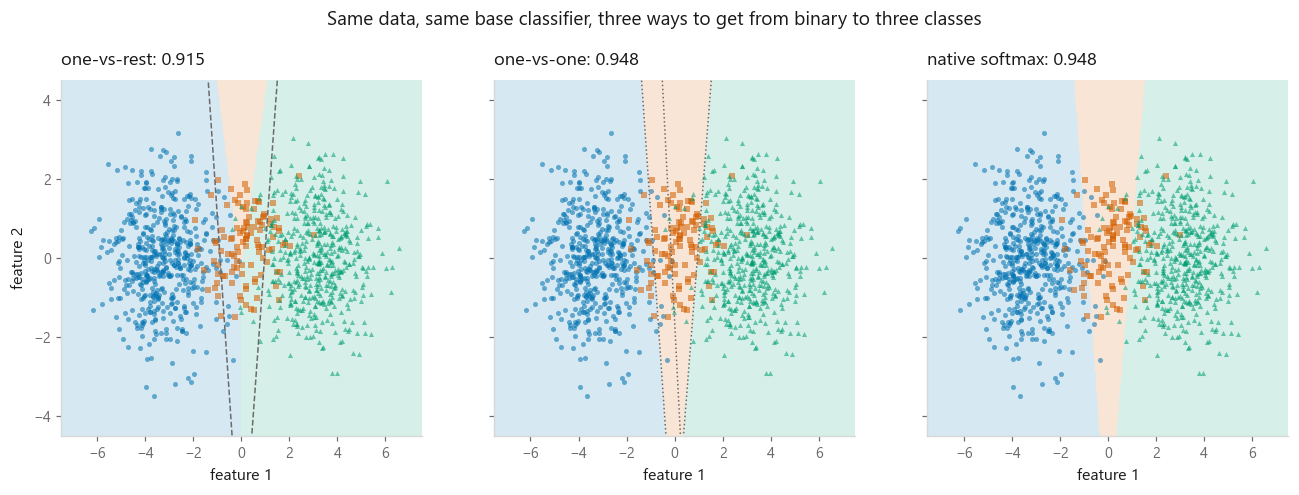

In [3]:
grid_x, grid_y = np.meshgrid(np.linspace(-7.5, 7.5, 500), np.linspace(-4.5, 4.5, 400))
grid = np.c_[grid_x.ravel(), grid_y.ravel()]
regions = ListedColormap([style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]])

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.2), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, toy_models.items()):
    ax.pcolormesh(grid_x, grid_y, model.predict(grid).reshape(grid_x.shape),
                  cmap=regions, alpha=0.16, shading="auto", zorder=0)

    # The binary sub-problems each strategy actually solved, drawn where they exist.
    if name == "one-vs-rest":
        for estimator in model.estimators_:
            ax.contour(grid_x, grid_y,
                       estimator.decision_function(grid).reshape(grid_x.shape),
                       levels=[0], colors=[style.MUTED], linewidths=1.0, linestyles="--")
    elif name == "one-vs-one":
        for estimator in model.estimators_:
            ax.contour(grid_x, grid_y,
                       estimator.decision_function(grid).reshape(grid_x.shape),
                       levels=[0], colors=[style.MUTED], linewidths=1.0, linestyles=":")

    for k, marker in enumerate(style.MARKERS[:3]):
        sel = y_toy == k
        ax.scatter(X_toy[sel, 0], X_toy[sel, 1], s=11, alpha=0.55, linewidths=0,
                   marker=marker, c=[style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]][k])

    ax.set_xlabel("feature 1")
    ax.grid(False)
    style.title(ax, f"{name}: {model.score(X_toy_eval, y_toy_eval):.3f}")

axes[0].set_ylabel("feature 2")
fig.suptitle("Same data, same base classifier, three ways to get from binary to three classes",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-three-strategies.png")

The dashed lines in the left panel are the three binary problems one-vs-rest
actually solved, and the middle one is the interesting failure. "Class 1 against
everything else" is not linearly separable at all: class 1 sits between the other
two, so no straight line puts it on one side. That binary model comes out close
to useless on its own.

It does not follow that one-vs-rest collapses, and the printed share of rows
assigned to the middle class says whether it did. scikit-learn does not use the
textbook sign rule, where a row with three negative votes has no answer. It takes
the **argmax of the raw decision functions**, so a nearly flat, slightly negative
score can still win when the other two are strongly negative.

That dodge has a price, and it is the real weakness of one-vs-rest. The seven
scores being compared come from seven models that were fitted separately and were
never asked to agree on a scale. Section 4 measures what that costs on the beans,
where one variety is several times rarer than another.

## 2. The maths, which is mostly counting

With $K$ classes and $n$ rows:

| | models fitted | rows seen, summed over models |
|---|---|---|
| native | 1 | $n$ |
| one-vs-rest | $K$ | $Kn$ |
| one-vs-one | $\tfrac{1}{2}K(K-1)$ | $(K-1)\,n$ |

The last cell is the one people get wrong. One-vs-one fits far more models, and
it feeds them **less** data in total, because the model for varieties $i$ and $j$
only ever sees rows from $i$ and $j$:

$$\sum_{i<j} (n_i + n_j) \;=\; \sum_i (K-1)\,n_i \;=\; (K-1)\,n$$

Each class appears in exactly $K-1$ pairs, so every row is used $K-1$ times
rather than $K$ times. For a classifier whose cost grows linearly with rows,
one-vs-one is therefore slightly cheaper than one-vs-rest despite fitting
twenty-one models instead of seven. For a classifier whose cost grows with the
square of rows, such as a kernel SVM, it is dramatically cheaper, because
twenty-one small squares beat seven large ones. Section 4 puts a stopwatch on it.

In [4]:
X, y = datasets.dry_bean()
counts = y.value_counts().sort_index()
n, K = len(y), y.nunique()

print(f"{n:,} beans, {K} varieties")
print(counts.to_string())
print(f"\nimbalance, largest over smallest: {counts.max() / counts.min():.2f}x\n")

budget = pd.DataFrame([
    {"strategy": "native", "models": 1, "rows seen": n},
    {"strategy": "one-vs-rest", "models": K, "rows seen": K * n},
    {"strategy": "one-vs-one", "models": K * (K - 1) // 2, "rows seen": (K - 1) * n},
])
budget["rows per model"] = (budget["rows seen"] / budget["models"]).round(0).astype(int)
print(budget.to_string(index=False))

13,611 beans, 7 varieties
Class
BARBUNYA    1322
BOMBAY       522
CALI        1630
DERMASON    3546
HOROZ       1928
SEKER       2027
SIRA        2636

imbalance, largest over smallest: 6.79x

   strategy  models  rows seen  rows per model
     native       1      13611           13611
one-vs-rest       7      95277           13611
 one-vs-one      21      81666            3889


## 3. From scratch

Both wrappers are short. What is worth writing out is the prediction rule, since
that is where the two strategies differ and where one-vs-one hides a decision
nobody documents.

In [5]:
from sklearn.base import clone


class OneVsRestScratch:
    """One binary model per class, then take the largest score."""

    def __init__(self, base):
        self.base = base

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self.classes_ = np.unique(y)
        self.models_ = [clone(self.base).fit(X, (y == c).astype(int)) for c in self.classes_]
        return self

    def decision(self, X):
        # One column per class. Nothing has made these columns comparable to each
        # other: each came from a model fitted on its own, unbalanced problem.
        return np.column_stack([m.decision_function(np.asarray(X)) for m in self.models_])

    def predict(self, X):
        return self.classes_[self.decision(X).argmax(axis=1)]


class OneVsOneScratch:
    """One binary model per pair of classes, then count votes."""

    def __init__(self, base):
        self.base = base

    def fit(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        self.classes_ = np.unique(y)
        self.pairs_, self.models_ = [], []
        for a, b in combinations(self.classes_, 2):
            rows = np.isin(y, [a, b])
            # Only the rows of these two varieties. This is why one-vs-one sees
            # fewer rows overall than one-vs-rest.
            self.models_.append(clone(self.base).fit(X[rows], (y[rows] == b).astype(int)))
            self.pairs_.append((a, b))
        return self

    def votes(self, X):
        X = np.asarray(X)
        index = {c: i for i, c in enumerate(self.classes_)}
        tally = np.zeros((len(X), len(self.classes_)))
        for (a, b), model in zip(self.pairs_, self.models_):
            picked = model.predict(X)
            tally[picked == 0, index[a]] += 1
            tally[picked == 1, index[b]] += 1
        return tally

    def predict(self, X):
        tally = self.votes(X)
        # argmax breaks a tie by taking the lowest class index, which is arbitrary.
        # scikit-learn breaks it with summed decision values instead. The rate below
        # is how often that choice is being made at all.
        self.tie_rate_ = float(((tally == tally.max(axis=1, keepdims=True)).sum(axis=1) > 1).mean())
        return self.classes_[tally.argmax(axis=1)]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25, stratify=y, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

mine_ovr = OneVsRestScratch(LogisticRegression(max_iter=3000)).fit(X_train_s, y_train)
mine_ovo = OneVsOneScratch(LogisticRegression(max_iter=3000)).fit(X_train_s, y_train)
theirs_ovr = OneVsRestClassifier(LogisticRegression(max_iter=3000)).fit(X_train_s, y_train)
theirs_ovo = OneVsOneClassifier(LogisticRegression(max_iter=3000)).fit(X_train_s, y_train)

ovo_guess = mine_ovo.predict(X_test_s)
print(f"one-vs-rest, ours against scikit-learn : "
      f"{(mine_ovr.predict(X_test_s) == theirs_ovr.predict(X_test_s)).mean():.4f} agreement")
print(f"one-vs-one,  ours against scikit-learn : "
      f"{(ovo_guess == theirs_ovo.predict(X_test_s)).mean():.4f} agreement")
print(f"binary models fitted: {len(mine_ovr.models_)} for one-vs-rest, "
      f"{len(mine_ovo.models_)} for one-vs-one")
print(f"test rows where the one-vs-one vote was tied: {mine_ovo.tie_rate_:.4f}")

one-vs-rest, ours against scikit-learn : 1.0000 agreement
one-vs-one,  ours against scikit-learn : 0.9994 agreement
binary models fitted: 7 for one-vs-rest, 21 for one-vs-one
test rows where the one-vs-one vote was tied: 0.0006


The one-vs-one agreement is the number to watch. Twenty-one voters and seven
candidates leave room for a tie, and when there is one, my `argmax` takes the
lowest-numbered variety while scikit-learn adds up the underlying decision values
and takes the largest sum. Neither rule is wrong. The printed tie rate says how
many rows the choice touches, and it is the ceiling on how far the two
implementations can drift apart.

This is the kind of detail that never appears in a tutorial and then explains a
reproducibility bug six months later.

## 4. In practice: three strategies, one dataset

Same base classifier, same split, same scaling. What changes is only the wrapper
around it.

In [7]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

strategies = {
    "native softmax": LogisticRegression(max_iter=3000),
    "one-vs-rest": OneVsRestClassifier(LogisticRegression(max_iter=3000)),
    "one-vs-one": OneVsOneClassifier(LogisticRegression(max_iter=3000)),
}

fitted, predictions, report = {}, {}, []
for name, estimator in strategies.items():
    started = time.perf_counter()
    model = estimator.fit(X_train_s, y_train)
    elapsed = time.perf_counter() - started

    guess = model.predict(X_test_s)
    fitted[name], predictions[name] = model, guess
    report.append({
        "strategy": name,
        "models": 1 if not hasattr(model, "estimators_") else len(model.estimators_),
        "accuracy": accuracy_score(y_test, guess),
        "balanced": balanced_accuracy_score(y_test, guess),
        "fit seconds": elapsed,
    })

report = pd.DataFrame(report)
print(report.round(4).to_string(index=False))

best_plain = report.loc[report["accuracy"].idxmax(), "strategy"]
best_balanced = report.loc[report["balanced"].idxmax(), "strategy"]
print(f"\nhighest accuracy          : {best_plain}")
print(f"highest balanced accuracy : {best_balanced}")
print(f"the two metrics agree on the winner: {best_plain == best_balanced}")

      strategy  models  accuracy  balanced  fit seconds
native softmax       1    0.9245    0.9366       0.2142
   one-vs-rest       7    0.9148    0.9272       0.1587
    one-vs-one      21    0.9251    0.9376       0.2558

highest accuracy          : one-vs-one
highest balanced accuracy : one-vs-one
the two metrics agree on the winner: True


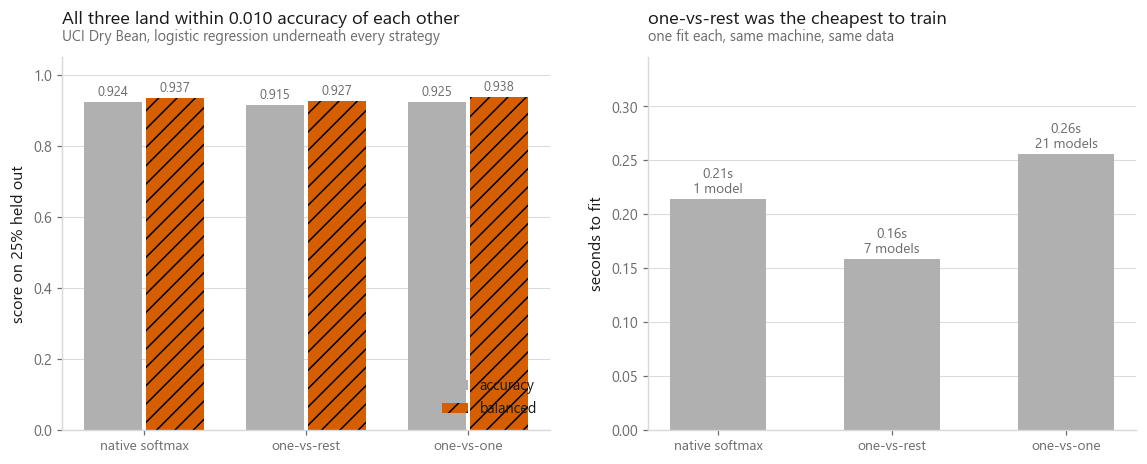

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
positions = np.arange(len(report))

for offset, column, colour, hatch in [(-0.19, "accuracy", style.NEUTRAL, ""),
                                      (0.19, "balanced", style.HIGHLIGHT, "//")]:
    axes[0].bar(positions + offset, report[column], width=0.36, color=colour,
                hatch=hatch, label=column)
    for x, value in zip(positions + offset, report[column]):
        axes[0].annotate(f"{value:.3f}", xy=(x, value), xytext=(0, 4),
                         textcoords="offset points", ha="center", fontsize=8.5,
                         color=style.MUTED)
axes[0].set_xticks(positions, report["strategy"], fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("score on 25% held out")
axes[0].legend(loc="lower right")
spread = report["accuracy"].max() - report["accuracy"].min()
style.title(axes[0], f"All three land within {spread:.3f} accuracy of each other",
            "UCI Dry Bean, logistic regression underneath every strategy")

axes[1].bar(positions, report["fit seconds"], width=0.55, color=style.NEUTRAL)
for x, seconds, models in zip(positions, report["fit seconds"], report["models"]):
    axes[1].annotate(f"{seconds:.2f}s\n{models} model{'s' if models > 1 else ''}",
                     xy=(x, seconds), xytext=(0, 4), textcoords="offset points",
                     ha="center", fontsize=9, color=style.MUTED)
axes[1].set_xticks(positions, report["strategy"], fontsize=9)
axes[1].set_ylabel("seconds to fit")
axes[1].set_ylim(0, report["fit seconds"].max() * 1.35)
cheapest = report.loc[report["fit seconds"].idxmin(), "strategy"]
style.title(axes[1], f"{cheapest} was the cheapest to train",
            "one fit each, same machine, same data")

style.save(fig, FIG / "fig-02-cost-and-accuracy.png")

Accuracy barely moves and the cost does. That is the shape of this comparison on
a linear model, and it is why the wrapper is usually a performance decision
rather than an accuracy one.

The place it stops being a performance detail is when the base learner's cost
grows faster than linearly in the number of rows. A kernel SVM is roughly
quadratic, so the $(K-1)n$ against $Kn$ arithmetic from section 2 turns into
something much larger. The check below uses a subsample, because running an RBF
kernel over all 13,611 beans several times would blow the notebook's time budget.

In [9]:
from sklearn.svm import SVC

subset = np.random.default_rng(SEED).choice(len(X_train_s), 3000, replace=False)
X_small, y_small = X_train_s[subset], y_train[subset]

kernel_cost = []
for name, estimator in [("one-vs-rest", OneVsRestClassifier(SVC(kernel="rbf"))),
                        ("one-vs-one", OneVsOneClassifier(SVC(kernel="rbf")))]:
    started = time.perf_counter()
    model = estimator.fit(X_small, y_small)
    kernel_cost.append({"strategy": name, "models": len(model.estimators_),
                        "fit seconds": time.perf_counter() - started,
                        "accuracy": model.score(X_test_s, y_test)})

kernel_cost = pd.DataFrame(kernel_cost)
print(f"RBF kernel SVM on {len(X_small):,} beans")
print(kernel_cost.round(4).to_string(index=False))
ratio = kernel_cost["fit seconds"].iloc[0] / kernel_cost["fit seconds"].iloc[1]
print(f"\none-vs-rest took {ratio:.2f}x as long as one-vs-one, "
      f"while fitting {kernel_cost['models'].iloc[1] // kernel_cost['models'].iloc[0]}x fewer models")
print("scikit-learn's own SVC already does one-vs-one internally, for exactly this reason")

RBF kernel SVM on 3,000 beans
   strategy  models  fit seconds  accuracy
one-vs-rest       7       0.3739    0.9289
 one-vs-one      21       0.1252    0.9280

one-vs-rest took 2.99x as long as one-vs-one, while fitting 3x fewer models
scikit-learn's own SVC already does one-vs-one internally, for exactly this reason


### What each strategy does to the confusion matrix

The aggregate scores hide the interesting part. Seven varieties are not equally
common and not equally easy, so the question is whether the strategies redistribute
their mistakes rather than change how many they make.

In [10]:
labels = sorted(np.unique(y_test))
matrices = {name: confusion_matrix(y_test, guess, labels=labels, normalize="true")
            for name, guess in predictions.items()}

recall = pd.DataFrame({name: m.diagonal() for name, m in matrices.items()}, index=labels)
recall.insert(0, "test rows", [int((y_test == c).sum()) for c in labels])
recall = recall.sort_values("test rows")
print("recall per variety, rarest first")
print(recall.round(4).to_string())

rare = recall.index[0]
print(f"\nrarest variety is {rare}")
for name in strategies:
    print(f"  {name:<15} recall {recall.loc[rare, name]:.4f}")

recall per variety, rarest first
          test rows  native softmax  one-vs-rest  one-vs-one
BOMBAY          130          1.0000       1.0000      1.0000
BARBUNYA        330          0.9212       0.9030      0.9303
CALI            408          0.9412       0.9240      0.9436
HOROZ           482          0.9606       0.9544      0.9627
SEKER           507          0.9389       0.9211      0.9349
SIRA            659          0.8877       0.8983      0.8816
DERMASON        887          0.9064       0.8895      0.9098

rarest variety is BOMBAY
  native softmax  recall 1.0000
  one-vs-rest     recall 1.0000
  one-vs-one      recall 1.0000


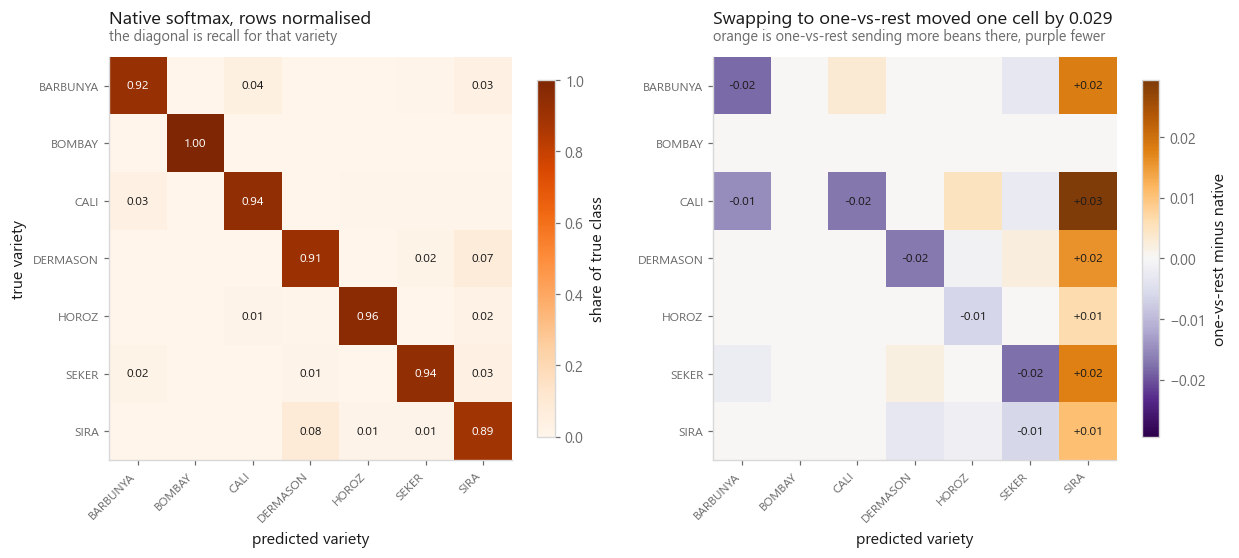

In [11]:
difference = matrices["one-vs-rest"] - matrices["native softmax"]
limit = max(np.abs(difference).max(), 1e-3)     # a floor, so an identical pair still renders

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4))

image = axes[0].imshow(matrices["native softmax"], cmap="Oranges", vmin=0, vmax=1)
for i in range(len(labels)):
    for j in range(len(labels)):
        if matrices["native softmax"][i, j] >= 0.01:
            axes[0].text(j, i, f"{matrices['native softmax'][i, j]:.2f}",
                         ha="center", va="center", fontsize=8,
                         color="white" if matrices["native softmax"][i, j] > 0.55 else style.INK)
fig.colorbar(image, ax=axes[0], shrink=0.78, label="share of true class")
style.title(axes[0], "Native softmax, rows normalised",
            "the diagonal is recall for that variety")

shift = axes[1].imshow(difference, cmap="PuOr_r", vmin=-limit, vmax=limit)
for i in range(len(labels)):
    for j in range(len(labels)):
        if abs(difference[i, j]) >= 0.005:
            axes[1].text(j, i, f"{difference[i, j]:+.2f}", ha="center", va="center",
                         fontsize=8, color=style.INK)
fig.colorbar(shift, ax=axes[1], shrink=0.78, label="one-vs-rest minus native")
style.title(axes[1], f"Swapping to one-vs-rest moved one cell by {limit:.3f}",
            "orange is one-vs-rest sending more beans there, purple fewer")

for ax in axes:
    ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(labels)), labels, fontsize=8)
    ax.set_xlabel("predicted variety")
    ax.grid(False)
axes[0].set_ylabel("true variety")
style.save(fig, FIG / "fig-03-confusion-shift.png")

### Where they actually disagree

Two models with the same accuracy are not the same model. The rows below are the
ones where the strategies part company, and the question worth asking about them
is not how many there are but who is right on them.

In [12]:
pairs = list(combinations(predictions, 2))
for a, b in pairs:
    print(f"{a:<15} vs {b:<15} disagree on "
          f"{(predictions[a] != predictions[b]).mean():.4f} of held-out rows")

stacked = np.column_stack([predictions[name] for name in predictions])
contested = np.array([len(set(row)) > 1 for row in stacked])
print(f"\nrows where at least one strategy differs: {contested.sum():,} "
      f"of {len(y_test):,} ({contested.mean():.4f})")

if contested.any():
    print("\naccuracy restricted to those contested rows:")
    for name in predictions:
        print(f"  {name:<15} {(predictions[name][contested] == y_test[contested]).mean():.4f}")
    # Only a few hundred rows are contested, so these three numbers are noisy.
    # Print the scale, or the temptation to rank them is irresistible.
    print(f"  standard error on each of those, over {int(contested.sum())} rows: "
          f"{np.sqrt(0.25 / contested.sum()):.4f}")
    print("\nvarieties most often involved in a disagreement:")
    involved = pd.Series(y_test[contested]).value_counts()
    share = (involved / pd.Series(y_test).value_counts()).sort_values(ascending=False)
    print(share.head(4).round(4).to_string())

native softmax  vs one-vs-rest     disagree on 0.0238 of held-out rows
native softmax  vs one-vs-one      disagree on 0.0088 of held-out rows
one-vs-rest     vs one-vs-one      disagree on 0.0300 of held-out rows

rows where at least one strategy differs: 106 of 3,403 (0.0311)

accuracy restricted to those contested rows:
  native softmax  0.5943
  one-vs-rest     0.2830
  one-vs-one      0.6132
  standard error on each of those, over 106 rows: 0.0486

varieties most often involved in a disagreement:
CALI        0.0466
BARBUNYA    0.0455
SEKER       0.0316
DERMASON    0.0293


This is the block that rescues the section, because the aggregate scores said the
three strategies were interchangeable and the contested rows say something else
entirely.

Read the three accuracies against the standard error printed beneath them. Two of
them sit well inside it of each other and one does not: one-vs-rest is right on a
far smaller share of the rows where the strategies part company, by a margin
several standard errors wide even on a few hundred rows. Native softmax and
one-vs-one are close to being the same model. One-vs-rest is the odd one out.

The mechanism is the one section 2 predicted. One-vs-rest picks a winner by
comparing scores from $K$ separately fitted binary models, and nothing ever put
those scores on a common scale. Each model was trained against a different
negative set, so a score of 2 from one of them and a score of 2 from another are
not the same claim. When one model is confident and the rest are ambivalent the
comparison is fine, which is why the aggregate accuracy is fine. On the close
calls, which is exactly what a contested row is, the comparison is between
quantities that were never made comparable.

So the aggregate said the wrapper does not matter and the conditional says it
matters on precisely the rows where anything is at stake. That is worth a rule.
**When two models score the same, look at the rows where they disagree before
concluding they are the same model.** It costs one boolean mask, and here it is
the difference between "pick on cost" and "pick on cost unless the close calls
are the ones you are paid for".

The varieties list narrows it further. Disagreement is not spread evenly across
the seven varieties, it concentrates on the ones whose measurements overlap most,
and those are the same varieties every confusion matrix in this chapter struggles
with. That says where the effort should go: not into the wrapper, which is
arguing over a hundred rows, but into a feature that separates the two varieties
at the top of that list. [03-09](../09-probability-calibration/) is the other
route, since putting the $K$ scores on a common scale is exactly what calibration
does.

## 5. When each wins, and where multilabel changes the question

For a linear base learner on this data the three strategies are interchangeable
on aggregate accuracy, and the table in section 4 says by how little. They are
not interchangeable on the contested rows, which is the qualification the section
above earned.

So: pick on cost, with one exception. Native if the model has it. One-vs-one when
the base learner scales worse than linearly. One-vs-rest only when you need one
readable binary model per class, and not when the close calls are the rows you
are judged on, because that is where its uncalibrated scores show up.

### Multilabel is not multiclass with more classes

Everything above assumed the classes are mutually exclusive. A bean is one
variety. Change that assumption and almost every habit breaks.

In a **multilabel** problem a row carries a *set* of labels. A photograph is
outdoors and contains a dog and was taken at night. A film is a comedy and a
musical. The target is no longer one column of class names; it is a matrix of
zeros and ones, one column per label, and the columns are usually not independent.

There is no multilabel dataset among the five house datasets, so I build one from
Dry Bean and I build it so that I control the one property that matters.

Four labels come from four shape descriptors, each thresholded at a fixed
quantile so every label ends up equally common. Then a **hidden factor** is added
to each label's score before
thresholding: one number per bean that the model never sees. Because the same
hidden number pushes all four labels in the same direction, the labels stay
correlated even after the model has extracted everything the features can tell
it. That leftover correlation is the only thing a classifier chain can use, and
building it deliberately is the only way to know whether the chain used it.

The control regime is identical except that each label gets its **own**
independent hidden factor. Same difficulty, same noise, no shared component.

In [13]:
SOURCES = ["AspectRation", "roundness", "Solidity", "Extent"]
LABELS = ["elongated", "round", "solid", "boxy"]
ALPHA = 1.0            # how loudly the hidden factor speaks, relative to the feature
JITTER = 0.30          # per-label measurement noise on top


def build_multilabel(shared_hidden, seed=SEED):
    """Four correlated binary labels, with a hidden factor the features cannot reveal."""
    rng = np.random.default_rng(seed)
    z = X[SOURCES].to_numpy(dtype=float)
    z = (z - z.mean(axis=0)) / z.std(axis=0)

    if shared_hidden:
        hidden = np.repeat(rng.normal(size=(len(z), 1)), len(SOURCES), axis=1)
    else:
        hidden = rng.normal(size=z.shape)

    score = z + ALPHA * hidden + JITTER * rng.normal(size=z.shape)
    # A fixed quantile per label, so both regimes have identical label prevalence
    # and only the correlation structure differs.
    return (score > np.quantile(score, 0.70, axis=0)).astype(int)


Y_shared = build_multilabel(shared_hidden=True)
Y_separate = build_multilabel(shared_hidden=False)

print("label prevalence (shared regime):")
for name, column in zip(LABELS, Y_shared.T):
    print(f"  {name:<10} {column.mean():.4f}")
print(f"\nrows carrying no label at all : {(Y_shared.sum(axis=1) == 0).mean():.4f}")
print(f"rows carrying all four labels : {(Y_shared.sum(axis=1) == 4).mean():.4f}")
print(f"average labels per row        : {Y_shared.sum(axis=1).mean():.4f}")

label prevalence (shared regime):
  elongated  0.3000
  round      0.3000
  solid      0.3000
  boxy       0.3000

rows carrying no label at all : 0.4281
rows carrying all four labels : 0.0686
average labels per row        : 1.1999


### Why accuracy is the wrong word here

`accuracy_score` on a label matrix means **subset accuracy**: every one of the
four labels has to be right or the row scores zero. That is a legitimate metric
and it is almost never the one you want, because it cannot tell a near miss from
a total miss.

The demonstration below needs no model at all. Take the true labels and flip
exactly one of them on every row.

In [14]:
from sklearn.metrics import accuracy_score as subset_accuracy
from sklearn.metrics import f1_score, hamming_loss

rng = np.random.default_rng(SEED)
almost = Y_shared.copy()
flip = rng.integers(0, len(LABELS), len(Y_shared))
almost[np.arange(len(Y_shared)), flip] ^= 1        # exactly one label wrong per row

print("a predictor that is wrong about exactly one label on every single row:")
print(f"  subset accuracy : {subset_accuracy(Y_shared, almost):.4f}")
print(f"  Hamming loss    : {hamming_loss(Y_shared, almost):.4f}")
print(f"  macro F1        : {f1_score(Y_shared, almost, average='macro', zero_division=0):.4f}")

nothing = np.zeros_like(Y_shared)
print("\na predictor that gives up and returns no labels at all:")
print(f"  subset accuracy : {subset_accuracy(Y_shared, nothing):.4f}")
print(f"  Hamming loss    : {hamming_loss(Y_shared, nothing):.4f}")
print(f"  macro F1        : {f1_score(Y_shared, nothing, average='macro', zero_division=0):.4f}")

a predictor that is wrong about exactly one label on every single row:
  subset accuracy : 0.0000
  Hamming loss    : 0.2500
  macro F1        : 0.6419

a predictor that gives up and returns no labels at all:
  subset accuracy : 0.4281
  Hamming loss    : 0.3000
  macro F1        : 0.0000


Two useless predictors, two very different profiles. The first gets three labels
out of four right on every row and scores nothing at all on subset accuracy,
which makes it look worse than it is. The second is right about every label it
never predicted, which is why its Hamming loss reads respectably, and F1 is the
metric that refuses to be fooled by it.

Report all three. Hamming loss for the average per-label error rate, subset
accuracy when a partly correct answer is worth nothing to your user, and per-label
F1 to catch a model that has quietly stopped predicting a label.

### Independent models against a chain

The obvious approach is **binary relevance**: one independent binary classifier
per label, four models, no communication between them. It is fast, it
parallelises, and by construction it cannot use the fact that a bean which is
elongated is unlikely to be boxy.

A **classifier chain** fixes labels in an order and gives each model the previous
labels as extra input columns. Label two sees the prediction for label one, and
so on. That lets the chain use exactly the leftover correlation the hidden factor
created.

One detail decides whether the chain works. During fitting, the extra columns can
be the *true* previous labels, which are unavailable at prediction time, or
cross-validated *predictions* of them, which are what the chain will really see.
`cv=5` asks for the second. Skipping it trains every link on inputs cleaner than
any it will ever meet again.

In [15]:
from sklearn.multioutput import ClassifierChain, MultiOutputClassifier

rows_train, rows_test = train_test_split(np.arange(len(X)), test_size=0.25,
                                         random_state=SEED)
# Scaler fitted on the training rows only. Fitting it on everything would leak the
# test set's spread into training, which is small here and free to avoid.
X_ml = StandardScaler().fit(X.values[rows_train]).transform(X.values)

base_ml = LogisticRegression(max_iter=1000)
forward, backward = list(range(len(LABELS))), list(range(len(LABELS)))[::-1]

multilabel_results, residual_correlation = [], {}
for regime, Y in [("shared hidden factor", Y_shared), ("separate hidden factors", Y_separate)]:
    Y_train, Y_test = Y[rows_train], Y[rows_test]

    approaches = {
        "independent binary": MultiOutputClassifier(clone(base_ml)),
        "chain, forward": ClassifierChain(clone(base_ml), order=forward, cv=5,
                                          random_state=SEED),
        "chain, reversed": ClassifierChain(clone(base_ml), order=backward, cv=5,
                                           random_state=SEED),
    }

    for name, estimator in approaches.items():
        model = estimator.fit(X_ml[rows_train], Y_train)
        guess = np.asarray(model.predict(X_ml[rows_test]))
        multilabel_results.append({
            "regime": regime, "approach": name,
            "subset accuracy": subset_accuracy(Y_test, guess),
            "hamming loss": hamming_loss(Y_test, guess),
            "micro F1": f1_score(Y_test, guess, average="micro", zero_division=0),
            "macro F1": f1_score(Y_test, guess, average="macro", zero_division=0),
        })

        # The residuals of the independent model are the leftover the chain feeds on.
        if name == "independent binary":
            probability = np.column_stack([p[:, 1] for p in model.predict_proba(X_ml[rows_test])])
            residual = Y_test - probability
            correlation = np.corrcoef(residual.T)
            off_diagonal = correlation[~np.eye(len(LABELS), dtype=bool)]
            residual_correlation[regime] = float(np.abs(off_diagonal).mean())

multilabel_results = pd.DataFrame(multilabel_results)
print(multilabel_results.round(4).to_string(index=False))

# Subset accuracy is a proportion over the held-out rows, so it has its own noise
# floor. Every chain-against-independent gap below has to clear about two of these
# before it is a gap rather than a coincidence.
se_subset = float(np.sqrt(0.25 / len(rows_test)))
print(f"\nstandard error on a subset accuracy over {len(rows_test):,} held-out rows, "
      f"at worst: {se_subset:.4f}")

print("\nmean absolute correlation between the four labels")
for regime, Y in [("shared hidden factor", Y_shared), ("separate hidden factors", Y_separate)]:
    marginal = np.corrcoef(Y.T)
    raw = np.abs(marginal[~np.eye(len(LABELS), dtype=bool)]).mean()
    print(f"  {regime:<26} before the model sees X: {raw:.4f}   "
          f"left over afterwards: {residual_correlation[regime]:.4f}")

                 regime           approach  subset accuracy  hamming loss  micro F1  macro F1
   shared hidden factor independent binary           0.4202        0.2424    0.5118    0.5079
   shared hidden factor     chain, forward           0.4229        0.2416    0.5130    0.5093
   shared hidden factor    chain, reversed           0.4199        0.2418    0.5126    0.5088
separate hidden factors independent binary           0.3209        0.2427    0.5134    0.5084
separate hidden factors     chain, forward           0.3209        0.2429    0.5128    0.5077
separate hidden factors    chain, reversed           0.3212        0.2428    0.5138    0.5090

standard error on a subset accuracy over 3,403 held-out rows, at worst: 0.0086

mean absolute correlation between the four labels
  shared hidden factor       before the model sees X: 0.3403   left over afterwards: 0.4730
  separate hidden factors    before the model sees X: 0.0914   left over afterwards: 0.0092


That second table is the mechanism, stated in one line per regime. Both regimes
have labels that correlate with each other before any model is involved, because
they were built from bean measurements that correlate. What separates them is how
much of that correlation survives once a model has read the features. A chain can
only feed on the leftover.

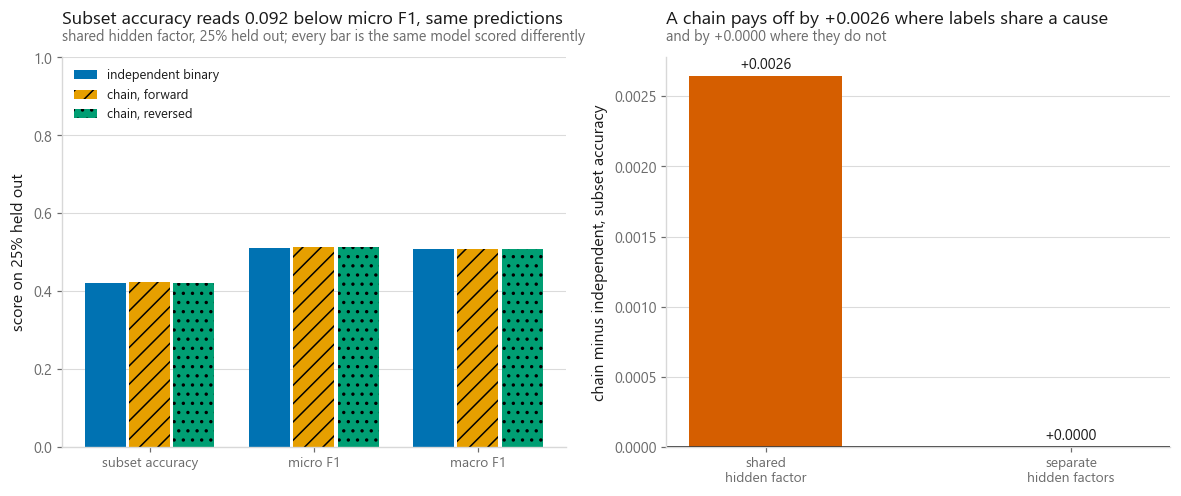

In [16]:
shared_rows = multilabel_results[multilabel_results["regime"] == "shared hidden factor"]
metrics = ["subset accuracy", "micro F1", "macro F1"]
approaches = list(shared_rows["approach"])

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
positions = np.arange(len(metrics))
for i, approach in enumerate(approaches):
    row = shared_rows[shared_rows["approach"] == approach].iloc[0]
    axes[0].bar(positions + (i - 1) * 0.27, [row[m] for m in metrics], width=0.25,
                color=style.PALETTE[i], hatch=["", "//", ".."][i], label=approach)
axes[0].set_xticks(positions, metrics, fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("score on 25% held out")
axes[0].legend(loc="upper left", fontsize=8.5)
independent_row = shared_rows[shared_rows["approach"] == "independent binary"].iloc[0]
harshness = independent_row["micro F1"] - independent_row["subset accuracy"]
style.title(axes[0], f"Subset accuracy reads {harshness:.3f} below micro F1, same predictions",
            "shared hidden factor, 25% held out; every bar is the same model scored differently")

gaps = []
for regime in ["shared hidden factor", "separate hidden factors"]:
    block = multilabel_results[multilabel_results["regime"] == regime].set_index("approach")
    gaps.append(block.loc["chain, forward", "subset accuracy"]
                - block.loc["independent binary", "subset accuracy"])

for x, value, hatch in [(0, gaps[0], ""), (1, gaps[1], "//")]:
    axes[1].bar([x], [value], width=0.5, hatch=hatch,
                color=style.HIGHLIGHT if value > 0 else style.NEUTRAL)
axes[1].axhline(0, color=style.INK, lw=1.1)
for x, value in zip([0, 1], gaps):
    axes[1].annotate(f"{value:+.4f}", xy=(x, value),
                     xytext=(0, 5 if value >= 0 else -14), textcoords="offset points",
                     ha="center", fontsize=9.5, color=style.INK)
axes[1].set_xticks([0, 1], ["shared\nhidden factor", "separate\nhidden factors"], fontsize=9)
axes[1].set_ylabel("chain minus independent, subset accuracy")
style.title(axes[1], f"A chain pays off by {gaps[0]:+.4f} where labels share a cause",
            f"and by {gaps[1]:+.4f} where they do not")

style.save(fig, FIG / "fig-04-multilabel-metrics.png")

The right panel is the whole argument for chains, and it is also the argument
against reaching for them by default. Read both bars against the standard error
printed above the table: the design of this experiment is that one of them should
clear it and the other should not, and the control regime exists precisely so
that a chain has a place to show no effect.

The gap is only there when something the features cannot explain links the
labels, which is what the residual-correlation line measures. When each label
carries its own private noise there is nothing left to pass along, and the chain
pays the cost of passing it anyway: an error in an early link propagates into
every later one, and the ordering becomes a hyperparameter you did not want.

Which is why the reversed chain is in the table. Two orders of the same method on
the same rows differ only in what each link is told, so any gap between them is
pure ordering effect, and the standard error says whether this dataset is large
enough to see it. The usual remedy does not depend on the answer: fit several
chains with random orders and average their probabilities, which removes the
question rather than answering it.

Per-label F1 is the last thing to look at, because a macro average can hide one
label the model has abandoned.

           independent binary  chain, forward  chain minus independent  position in chain
elongated              0.6085          0.6085                   0.0000                  1
round                  0.5308          0.5281                  -0.0027                  2
solid                  0.3755          0.3823                   0.0068                  3
boxy                   0.5169          0.5183                   0.0014                  4

label that gained most : solid, at chain position 3 of 4


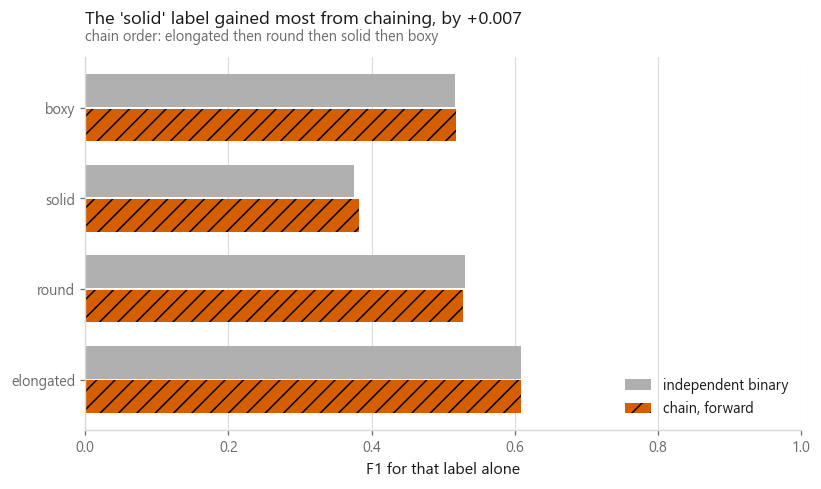

In [17]:
Y_train, Y_test = Y_shared[rows_train], Y_shared[rows_test]
per_label = {}
for name, estimator in [("independent binary", MultiOutputClassifier(clone(base_ml))),
                        ("chain, forward", ClassifierChain(clone(base_ml), order=forward,
                                                           cv=5, random_state=SEED))]:
    guess = np.asarray(estimator.fit(X_ml[rows_train], Y_train).predict(X_ml[rows_test]))
    per_label[name] = f1_score(Y_test, guess, average=None, zero_division=0)

per_label = pd.DataFrame(per_label, index=LABELS)
per_label["chain minus independent"] = per_label.iloc[:, 1] - per_label.iloc[:, 0]
# Position in the chain is the design's prediction for which label should gain, so
# put it in the table rather than asking the reader to hold the order in their head.
per_label["position in chain"] = [forward.index(i) + 1 for i in range(len(LABELS))]
print(per_label.round(4).to_string())
print(f"\nlabel that gained most : {per_label['chain minus independent'].idxmax()}, "
      f"at chain position "
      f"{int(per_label.loc[per_label['chain minus independent'].idxmax(), 'position in chain'])} "
      f"of {len(LABELS)}")

fig, ax = plt.subplots(figsize=(8.4, 4.4))
positions = np.arange(len(LABELS))
for i, name in enumerate(["independent binary", "chain, forward"]):
    ax.barh(positions + (0.19 if i == 0 else -0.19), per_label[name], height=0.36,
            color=[style.NEUTRAL, style.HIGHLIGHT][i], hatch=["", "//"][i], label=name)
ax.set_yticks(positions, LABELS)
ax.set_xlim(0, 1.0)
ax.set_xlabel("F1 for that label alone")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
moved = per_label["chain minus independent"]
verb = "gained" if moved.max() > 0 else "lost least"
style.title(ax, f"The '{moved.idxmax()}' label {verb} most from chaining, by {moved.max():+.3f}",
            f"chain order: {' then '.join(LABELS[i] for i in forward)}")
style.save(fig, FIG / "fig-05-per-label-f1.png")

The design predicts that the label gaining most sits late in the chain, because a
late label is handed the most extra columns and the first label is handed none at
all. The printed position column is that prediction made checkable.

Whichever way it comes out, the useful conclusion is the same and it is about how
to read a macro average rather than about chains. The per-label column moves in
both directions here: chaining is not a uniform improvement applied to four
labels, it is a redistribution, and a single macro F1 is the average of gains and
losses that partly cancel. If one of these four labels mattered more than the
others to whoever uses the output, the macro number would be the wrong thing to
optimise and this table would be the right one.

The failure a macro average hides completely is a label the model has stopped
predicting at all. That label scores zero F1, the other three carry the average,
and nothing in a summary line says a quarter of the output is dead. Look at the
column, not the mean of the column.

## Cheat sheet

| | |
|---|---|
| **Native multiclass** | Logistic regression, trees, forests, naive Bayes, most neural networks. One fit, no wrapper, use it if you have it |
| **One-vs-rest** | `OneVsRestClassifier`. $K$ models, $Kn$ rows of work, one interpretable binary model per class. Scores from different models are not on a common scale |
| **One-vs-one** | `OneVsOneClassifier`. $\tfrac{1}{2}K(K-1)$ models but only $(K-1)n$ rows of work. The right choice when the base learner scales worse than linearly, which is why `SVC` uses it internally |
| **Multilabel** | A matrix target, one column per label. `MultiOutputClassifier` for independent models, `ClassifierChain` when the labels share something the features do not explain |
| **Chains** | Use `cv=5` so each link trains on predicted rather than true previous labels. Order matters; averaging several random orders is the standard fix |
| **Metrics** | Hamming loss for the average label error, subset accuracy when partial credit is worthless, per-label F1 to catch an abandoned label. Never only one of them |
| **Watch out** | `accuracy_score` on a label matrix silently means subset accuracy, which is far harsher than most people expect |
| **Next** | [Probability calibration](../09-probability-calibration/), which is what makes one-vs-rest scores comparable in the first place |

## What to remember

1. One-vs-rest fits $K$ models and does $Kn$ rows of work. One-vs-one fits
   $\tfrac{1}{2}K(K-1)$ models and does only $(K-1)n$. More models, less work.
2. That arithmetic is why one-vs-one wins on kernel methods and barely matters on
   linear ones. Measure the cost, not the model count.
3. One-vs-rest compares scores from models that were never calibrated against
   each other. Its aggregate accuracy matched the others and its accuracy on the
   rows where the strategies disagreed did not, by a wide margin. Aggregate
   equality is not model equality.
4. When two models score the same, mask to the rows where they disagree and score
   them there. One boolean mask, and it separated three strategies that a
   leaderboard called identical.
5. One-vs-one has to break ties, and the tie-breaking rule is an undocumented
   choice that differs between implementations.
6. Multilabel is a different problem, not a harder multiclass. The target is a
   matrix and the labels are usually dependent.
7. `accuracy_score` on a multilabel target means all labels right or none. Report
   Hamming loss and per-label F1 beside it, always.
8. Classifier chains only pay when correlation survives conditioning on the
   features. Build a control where it does not, and check that the gain vanishes.
   Here the gain did not clear the standard error even in the regime built to
   produce one, so the bar for "enough leftover correlation" is higher than a
   notebook can conveniently construct.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-09 Probability calibration](../09-probability-calibration/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Multiclass` `#Multilabel` `#OneVsRest` `#OneVsOne`
`#ClassifierChains` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`